In [2]:
!pip install -q langchain-mistralai langgraph python-dotenv

In [3]:
from typing import Annotated

from langchain_mistralai import ChatMistralAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage

In [4]:
from google.colab import userdata
import os
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')

In [14]:
# DELIBERATELY hardcoded -- see MISTRAL_MODEL_LIMITS.md: mistral-small-latest
# has zero request allowance on many accounts.
llm = ChatMistralAI(model="ministral-8b-latest")

In [15]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [29]:
def chat_node(state: ChatState):

    decision = interrupt({
        "type": "approval",
        "reason": "Model is about to answer a user question.",
        "question": state["messages"][-1].content,
        "instruction": "Approve this question? yes/no"
    })

    # .strip().lower() normalizes the human's raw typed input -- never trust
    # an exact string match against what a person types (case, stray
    # whitespace, etc. can silently break a brittle == comparison).
    if decision["approved"].strip().lower() == 'no':
        return {"messages": [AIMessage(content="Not approved.")]}

    else:
        response = llm.invoke(state["messages"])
        return {"messages": [response]}

In [30]:
# 3. Build the graph: START -> chat -> END
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)

builder.add_edge(START, "chat")
builder.add_edge("chat", END)

# Checkpointer is required for interrupts
checkpointer = MemorySaver()

# Compile the app
app = builder.compile(checkpointer=checkpointer)

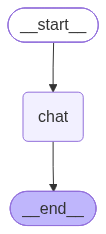

In [31]:
app

In [32]:
# Create a new thread id for this conversation
config = {"configurable": {"thread_id": '1234'}}

# ---- STEP 1: user asks a question ----
initial_input = {
    "messages": [
        ("user", "Explain gradient descent in very simple terms.")
    ]
}

# Invoke the graph for the first time
result = app.invoke(initial_input, config=config)

In [33]:
result

{'messages': [HumanMessage(content='Explain gradient descent in very simple terms.', additional_kwargs={}, response_metadata={}, id='ff0cc0c6-689a-44dd-8715-c496bd2e3fdb')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'}, id='d0cc6a6d0922c1337b1e59730d6eea67')]}

In [34]:
message = result['__interrupt__'][0].value
message

{'type': 'approval',
 'reason': 'Model is about to answer a user question.',
 'question': 'Explain gradient descent in very simple terms.',
 'instruction': 'Approve this question? yes/no'}

In [35]:
user_input = input(f"\nBackend message - {message} \n Approve this question? (y/n): ")


Backend message - {'type': 'approval', 'reason': 'Model is about to answer a user question.', 'question': 'Explain gradient descent in very simple terms.', 'instruction': 'Approve this question? yes/no'} 
 Approve this question? (y/n): no


In [36]:
# Resume the graph with the approval decision
final_result = app.invoke(
    Command(resume={"approved": user_input}),
    config=config,
)

In [37]:
print(final_result["messages"][-1].content)

Not approved.


In [38]:
print(repr(user_input))

'no'
